In [8]:
using Turing
using Jens, CUDA
using Jens:LensBase as LB
using Jens:LensUtils as LU
using Jens:LensFITS as LF
using Jens:LensGenerator as LG
using Jens:LensPlots as Jplots
using Jens:LensCosmo as LC
using Jens:LensPSF as LP

using Jens.LensModel.ComLens: CombinedLens
using Jens.LensModel: NFWE, Shear, SIS
using Jens.LightModel: CompositeImage, ExtendedSource, PointImage
using Jens.LightModel.SersicLight: SersicSpheric
using Jens.LensSystem: ForwardModel, render

In [2]:
# Cosmology + grid + PSF 
cosmo = LC.Cosmology.FlatLCDM(0.7, 0.3, 0.0, 0.0)
z_lens, z_src = 0.3, 1.5

grid_cpu = LG.GenGrid(pix_n=128, pix_size=0.08)              # CPU
grid_gpu = gpu_grid(pix_n=128, pix_size=Float32(0.08))  # GPU

psf = LP.GaussianPSF(; fwhm=0.12)

Jens.LensPSF.GaussianPSF{Float64}(0.12)

In [3]:
# Lens model
lens = CombinedLens(
    NFWE   => (Rs=5.0, alpha_Rs=1.0, e1=0.2, e2=0.1, xcentre=0.0, ycentre=0.0),
    Shear => (gamma1=0.05, gamma2=-0.03, xcentre=0.0, ycentre=0.0))

# Light model
# host
host = ExtendedSource(SersicSpheric;
    amp=1.0, Rsersic=0.3, n=2.0, xcentre=0.0, ycentre=0.0)

# point source
agn = PointImage(flux=50.0, beta_x=0.05, beta_y=-0.01)

# combine
src = CompositeImage(host, agn)

CompositeImage{Tuple{ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}, PointImage}}((ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}(Jens.LightModel.SersicLight.SersicSpheric, (amp = 1.0, Rsersic = 0.3, n = 2.0, xcentre = 0.0, ycentre = 0.0)), PointImage(50.0, 0.05, -0.01)))

In [4]:
sys = ForwardModel(
    lens_plane   = LG.LensedPlane(lens; z_lens, cosmology=cosmo),
    source_plane = LG.LightPlane(src; z=z_src),
    grid = grid_gpu, psf = psf,
)

img = render(sys);

129×129 CuArray{Float64, 2, CUDA.DeviceMemory}:
 2.20692e-8  2.88053e-8  3.13731e-8  …  4.94304e-8  4.54421e-8  3.48481e-8
 2.85298e-8  3.72575e-8  4.06061e-8     6.39347e-8  5.87312e-8  4.5012e-8
 3.06975e-8  4.01153e-8  4.37581e-8     6.88337e-8  6.317e-8    4.8377e-8
 3.2891e-8   4.30112e-8  4.69578e-8     7.37898e-8  6.76513e-8  5.17685e-8
 3.52305e-8  4.61024e-8  5.03769e-8     7.9071e-8   7.24206e-8  5.53745e-8
 3.77248e-8  4.94007e-8  5.40289e-8  …  8.46948e-8  7.74932e-8  5.92061e-8
 4.03823e-8  5.29181e-8  5.79276e-8     9.0679e-8   8.28839e-8  6.3274e-8
 4.32123e-8  5.66668e-8  6.20872e-8     9.70414e-8  8.86081e-8  6.75892e-8
 4.62239e-8  6.06595e-8  6.65225e-8     1.038e-7    9.46811e-8  7.21627e-8
 4.94268e-8  6.49095e-8  7.12486e-8     1.10974e-7  1.01118e-7  7.70056e-8
 ⋮                                   ⋱                          
 7.21627e-8  9.46811e-8  1.038e-7    …  6.65225e-8  6.06595e-8  4.62239e-8
 6.75892e-8  8.86081e-8  9.70414e-8     6.20872e-8  5.66668e-8  4

In [5]:
# SIM real img
data  = Float64.(Array(img))   

sigma = max(median(abs.(data)) * 0.1, 1e-3)           # noise

data_noisy = data .+ sigma .* randn(size(data));

In [ ]:
# likelihood
function logp_fn(p::Vector{Float64})
    theta_E, amp, Rsersic = p

    # 从参数重建模型
    m  = CombinedLens(SIS => (theta_E=theta_E, xcentre=0.0, ycentre=0.0))
    lp = LG.LensedPlane(m; z_lens, cosmology=cosmo)
    h  = ExtendedSource(SersicSpheric;
        amp=amp, Rsersic=Rsersic, n=2.0, xcentre=0.0, ycentre=0.0)
    a  = PointImage(flux=50.0, beta_x=0.05, beta_y=-0.03)  # 可固定或加入参数

    sys = ForwardModel(
        lens_plane   = lp,
        source_plane = LG.LightPlane(CompositeImage(h,a); z=z_src),
        grid = grid_gpu, psf = psf)

    img = render(sys)
    return -sum((data_noisy .- Float64.(Array(img))).^2) / (2*sigma^2)
end

logp_fn (generic function with 1 method)

In [16]:
using Jens.LensMH

lower = [0.2, 0.1, 0.05]    # prior bounds 
upper = [2.0, 5.0, 1.0]
init  = [0.75, 0.9, 0.35]

result = lens_mh(logp_fn, lower, upper;
    n     = 5000, 
    adapt = true,    # adaptive step
    init  = init,
    seed  = 42)

# n_chains for multi-thread
chains = lens_mh_multi(logp_fn, lower, upper;
    n_chains=4, n=5000, adapt=true)

4-element Vector{MHResult}:
 MHResult([1.1 1.1 … 0.9572482165053512 0.9572482165053512; 2.55 2.55 … 2.5166894703202667 2.5166894703202667; 0.525 0.525 … 0.5056809472080495 0.5056809472080495], [-1.0481936437608835e11, -1.0481936437608835e11, -1.043823689490628e11, -1.0435299298668173e11, -1.0435299298668173e11, -1.0382548401951778e11, -1.016562420075296e11, -1.0066647273997739e11, -1.0019584099066148e11, -1.0019584099066148e11  …  -7.923404728158472e10, -7.923404728158472e10, -7.923404728158472e10, -7.923404728158472e10, -7.923404728158472e10, -7.923404728158472e10, -7.923404728158472e10, -7.923404728158472e10, -7.923404728158472e10, -7.923404728158472e10], 93, [1.8e-5, 4.9000000000000005e-5, 9.499999999999999e-6])
 MHResult([1.0942209192368857 1.0880987293387547 … 1.0116701120448595 1.0116701120448595; 2.557906786560221 2.55575637802667 … 2.5374573433645793 2.5374573433645793; 0.5255297914065369 0.5230713943451955 … 0.5270600471150743 0.5270600471150743], [-1.0383156144315971e11, -1.0

In [18]:
# summary
summary = chain(result; burn=500)          # (n_params, n_samples) 
means, stds = chain_stats(result; burn=500)

([0.3741530329334225, 0.7128732653987571, 0.3407025277554628], [2.099979839313497e-7, 5.574911594975377e-5, 5.698186702354762e-6])

In [36]:
using StatsPlots,PairPlots, MCMCChains, CairoMakie

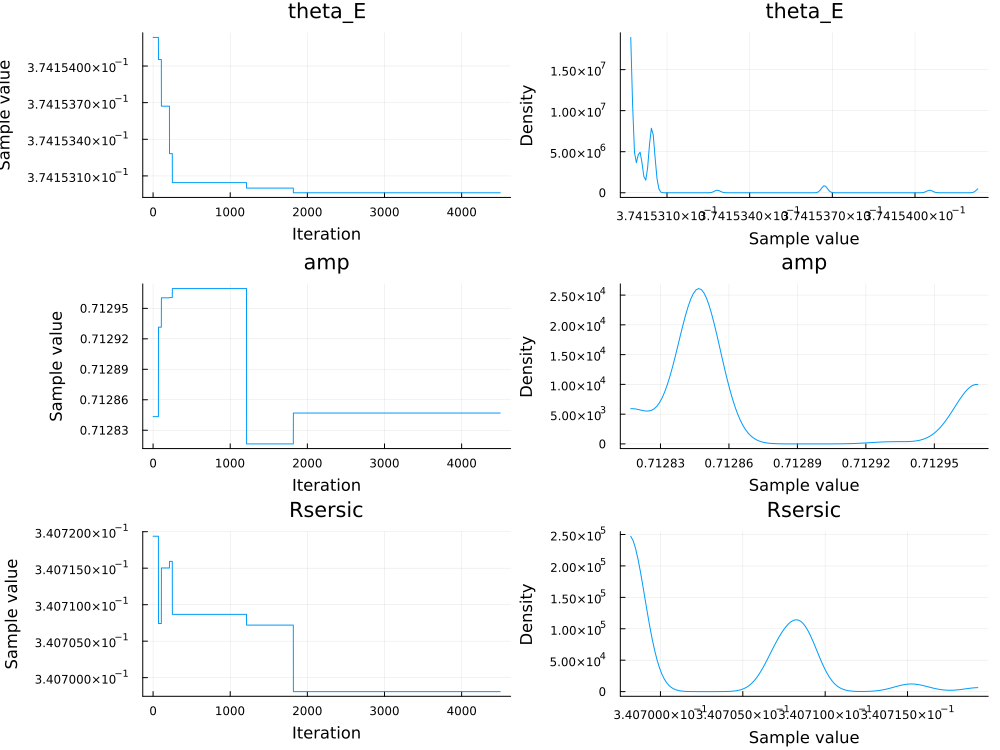

In [34]:
chn = Chains(summary', [:theta_E, :amp, :Rsersic])
ChainPlot = StatsPlots.plot(chn)

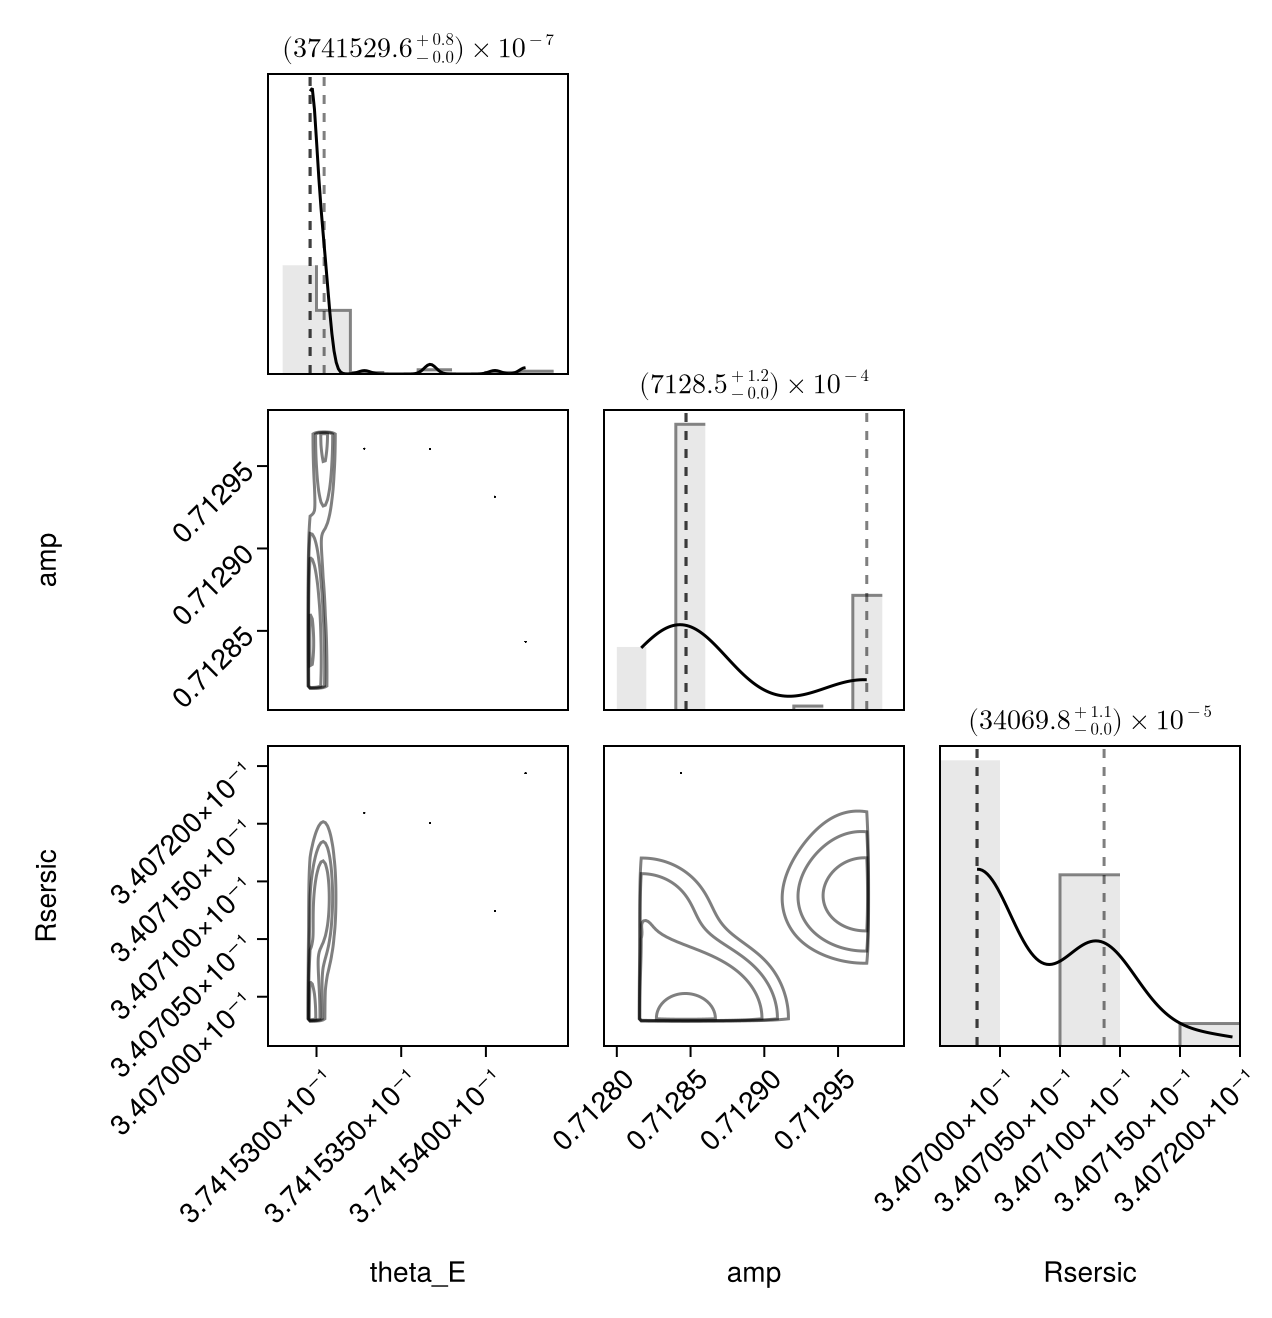

In [37]:
corner_fig = PairPlots.pairplot(chn)


|  MCMC 拟合速度（500 步自适应 MH，3 参数 SIS）                     |   
|  grid   |   CPU    |    GPU   |   加速比  |    ms/step(CPU) | ms/step(GPU)|
|------|------|------|------|------|------|
|   64²  |    0.5 s   |   1.7 s  |  0.3  |    1.0    |     3.4|
|  128²   |   0.8 s  |    0.3 s  |  2.7    |     1.7   |      0.6|
|  256²   |   6.9 s   |   0.4 s  | 19.1   |  13.9    |     0.7|